In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [89]:
items = pd.read_csv('stimuli/civ_items_trial_4.csv')

In [90]:
print('obj1 max:',items.iloc[:, 1].max(), ' obj1 min:',items.iloc[:, 1].min())
print('obj2 max:',items.iloc[:, 2].max(), ' obj2 min:',items.iloc[:, 2].min())
print('obj3 max:',items.iloc[:, 3].max(), ' obj3 min:',items.iloc[:, 3].min())
print('cons max:',items.iloc[:, 4].max(), ' cons min:',items.iloc[:, 4].min())
print('initial thresholds:', items.iloc[:, 1].min(), items.iloc[:, 2].min(), items.iloc[:, 3].min(), items.iloc[:, 4].max())

obj1 max: 19  obj1 min: 2
obj2 max: 18  obj2 min: 1
obj3 max: 16  obj3 min: 2
cons max: 19  cons min: 1
initial thresholds: 2 1 2 19


In [3]:
p_data_dir = '/data/knapsack/card_game_log/pilot_sub5'

for file in Path(p_data_dir).glob('*Trial8*'):
    print(file)
    data = pd.read_csv(file)

/data/knapsack/card_game_log/pilot_sub5/TrialLog_3847f7bc-2644-4a26-9e09-61da3395f10c_Trial8.csv


In [72]:
filt_op = data[data['operationType'].isin(['update'])].copy()
filt_op_info = filt_op[['sortKey', 'ascending', 'thresholdsPacked', 'visibleItemCount', 'visibleItemIdsPipe']]

In [ ]:
data['updateCount'] = data['operationType'].eq('update').cumsum()

num_update = data['updateCount'].max()
for i in range(1, num_update+1):
    section_data = data[data['updateCount'] == i]
    update_data = section_data.loc[section_data['operationType'] == 'update', ['sortKey', 'ascending', 'thresholdsPacked', 'visibleItemCount', 'visibleItemIdsPipe']]
    display(update_data)
    add_data = section_data.loc[section_data['operationType'] == 'add'].iloc[:, 4:10]
    display(add_data)

In [4]:
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()

mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')

card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

In [5]:
obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

In [6]:
# find closest pareto front
pf_data = pd.read_csv('eda_results/pf_trial8.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

In [7]:
print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

[ 77  51 126 111  86]
[ 75  55 125 109  89]
5.830951894845301


In [75]:
# check dominance
def calculate_dominance(pf_predicted, pf_actual, n_obj):
    dominance = np.zeros(len(pf_actual))
    for j in range(len(pf_actual)):
        if np.all(pf_actual[j, :n_obj] >= pf_predicted[:n_obj]) and \
            np.any(pf_actual[j, :n_obj] > pf_predicted[:n_obj]):
            dominance[j] = 1
    return dominance, np.sum(dominance), np.sum(dominance)/len(pf_actual)
dominance, num_dominance, ratio_dominance = calculate_dominance(obj_data_cumu[-1], pf_data, 5)
print(num_dominance)
print(ratio_dominance)

0.0
0.0


In [76]:
# check number of objectives won
def calculate_win(pf_predicted, pf_actual, n_obj):
    win = np.zeros(len(pf_actual))
    for j in range(len(pf_actual)):
        win[j] = np.sum(pf_actual[j, :n_obj] > pf_predicted[:n_obj])
    return win, np.mean(win)
num_win, mean_win = calculate_win(obj_data_cumu[-1], pf_data, 5)
print(num_win)
print(mean_win)

[2. 2. 3. ... 2. 2. 2.]
2.6515635322616165


In [ ]:
def calculate_win_r(pf_actual, pf_predicted, n_obj):
    win = np.zeros(len(pf_actual))
    for j in range(len(pf_actual)):
        win[j] = np.sum(pf_predicted[:n_obj] > pf_actual[j, :n_obj])
    return win, np.mean(win)
num_win, mean_win = calculate_win_r(obj_data_cumu[-1], pf_data, 5)
print(num_win)
print(mean_win)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], 'b-o', alpha=0.5, markersize=4)
ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], 'r-o', alpha=0.5, markersize=8)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

/data/knapsack/card_game_log/pilot_sub3/TrialLog_e1a48361-f230-409d-81f1-b8281ade8287_Trial3.csv
[62 74 68]
[62 76 68]
2.0


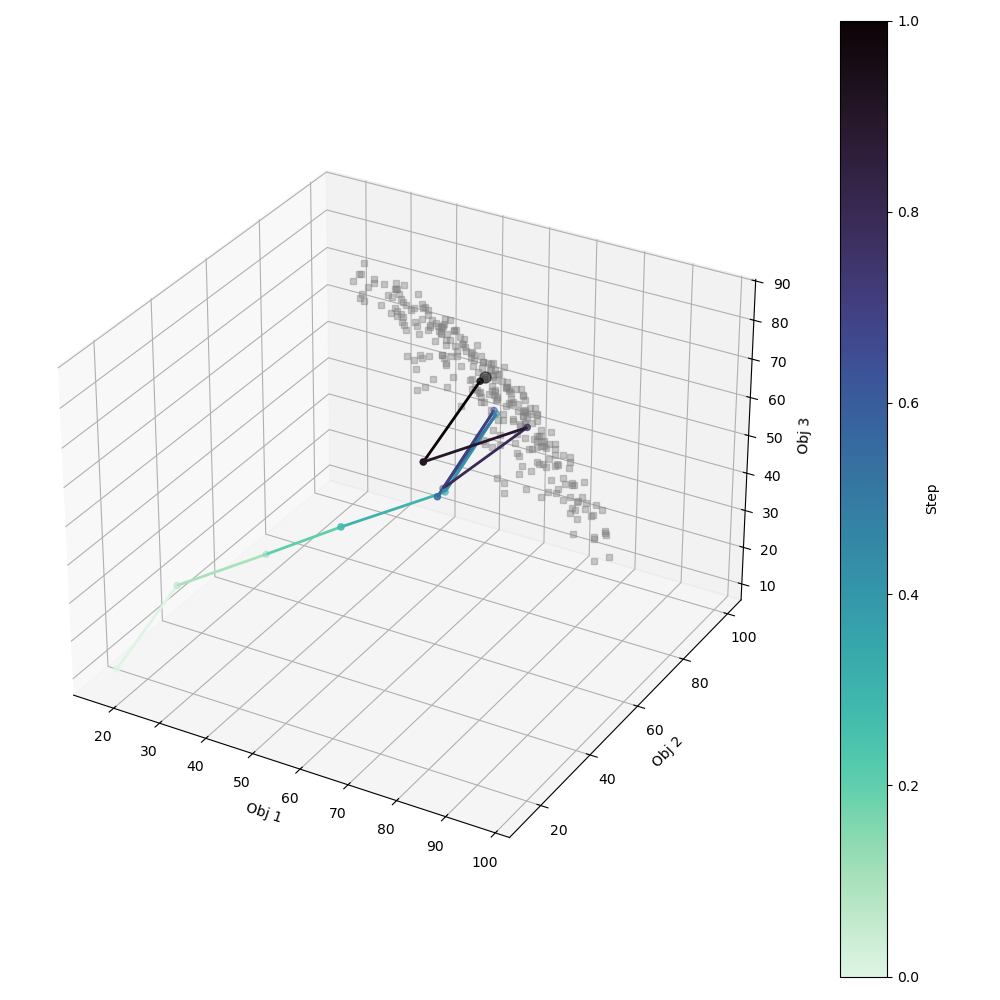

In [2]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
# colors = sns.color_palette("Set2", 6)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub3'

# for trial in range(2, 3):
trial = 3
for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
    print(file)
    data = pd.read_csv(file)

# add and remove  
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')
card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

# find closest pareto front
pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

ax.plot(pf_data[:,0], pf_data[:,1], pf_data[:,2], 's', alpha=0.4, markersize=4, color='grey')
# ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], '-o', alpha=0.9, markersize=4, color=colors)

# plot path
x = obj_data_cumu[:, 0]
y = obj_data_cumu[:, 1]
z = obj_data_cumu[:, 2]
points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
t = np.linspace(0, 1, len(x) - 1)
lc = Line3DCollection(segments, cmap="mako_r", linewidth=1)
lc.set_array(t)
lc.set_linewidth(2)
ax.add_collection(lc)
sc = ax.scatter(x, y, z, c=np.linspace(0,1,len(x)), cmap="mako_r", s=20)
plt.colorbar(sc, ax=ax, label='Step')

ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], '-o', alpha=0.5, markersize=8, color='black', markeredgecolor='black')

ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.tight_layout()
plt.show()

/data/knapsack/card_game_log/pilot_sub1/TrialLog_dd963e93-01ad-40a3-9109-bbca0cb666c9_Trial10.csv
[85 85 86 89 93]
[91 88 86 94 93]
8.366600265340756


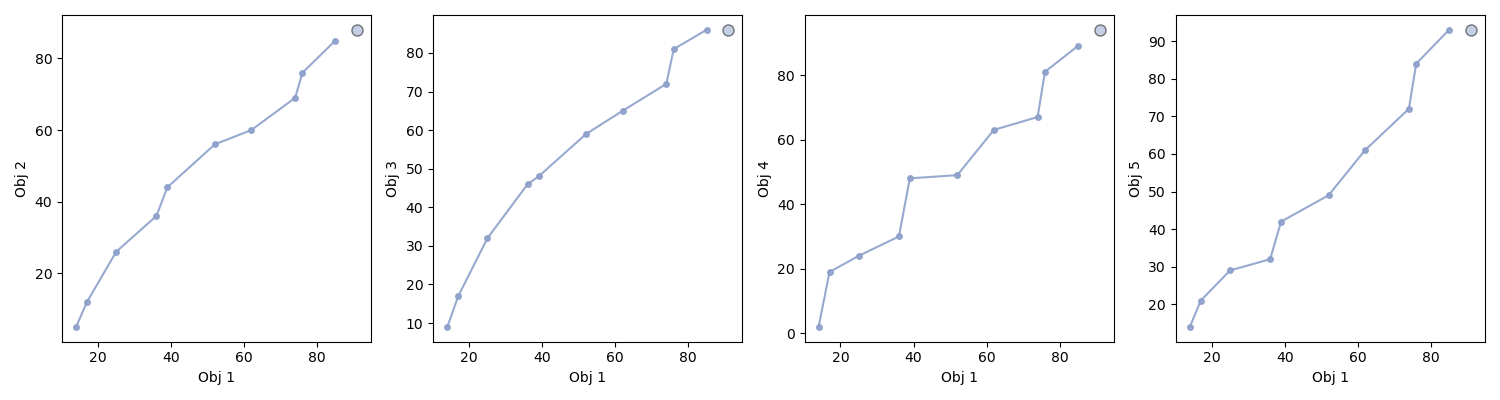

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = sns.color_palette("Set2", 3)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub1'

for trial in range(10, 11):
    for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
        print(file)
        data = pd.read_csv(file)

    # add and remove  
    card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
    mask_add = card_op['operationType'] == 'add'
    mask_remove = card_op['operationType'] == 'remove'
    mask_obj = card_op.columns.str.contains('itemObj')
    card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

    obj_data = card_op.loc[:, mask_obj].values
    obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

    # find closest pareto front
    pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
    dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
    idx = np.argmin(dists)
    closest_pf = pf_data[idx]
    closest_dist = dists[idx]

    print(obj_data_cumu[-1])
    print(closest_pf)
    print(closest_dist)

    for i in range(1, 5):
        # axes[i-1].plot(pf_data[:,0], pf_data[:,i], 's', alpha=0.2, markersize=4, color='grey')
        axes[i-1].plot(obj_data_cumu[:, 0], obj_data_cumu[:, i], '-o', alpha=0.9, markersize=4, color=colors[trial-8])
        axes[i-1].plot(closest_pf[0], closest_pf[i], '-o', alpha=0.5, markersize=8, color=colors[trial-8], markeredgecolor='black')
        axes[i-1].set_xlabel('Obj 1')
        axes[i-1].set_ylabel(f'Obj {i+1}')
plt.tight_layout()
plt.show()